# ELL784 / ELL7286 — Assignment 3
## Gesture Recognition on Soli Radar using Adversarial Training

This notebook implements a unified framework that addresses two core challenges in radar-based hand gesture recognition:

1. **Fine-grained gesture performance** — The four gestures (pinch index, pinch pinky, finger slide, finger rub) produce very similar sparse range-Doppler signatures. We train a conditional Wasserstein GAN to synthesize additional training samples for these classes.

2. **Cross-subject generalization** — Different users have different hand sizes, speeds, and motion patterns. We use a Domain-Adversarial Neural Network (DANN) with a Gradient Reversal Layer so the encoder learns subject-invariant features.

Both are combined into a single training pipeline.

---
**Before running:** Go to `Runtime → Change runtime type → T4 GPU → Save`

## 1. Environment Setup

In [2]:
import torch
import os

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > T4 GPU')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
!pip install h5py numpy matplotlib torch torchvision -q
print('All packages installed.')

All packages installed.


## 2. Upload and Extract the Soli Dataset


In [4]:
import zipfile

zip_path = '/content/SoliData.zip'
data_dir = '/content/dsp'

if not os.path.exists(zip_path):
    print('SoliData.zip not found. Please upload it first.')
else:
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/')

    h5_files = [f for f in os.listdir(data_dir) if f.endswith('.h5')]
    print(f'Done. Found {len(h5_files)} .h5 files in {data_dir}/')

Extracting dataset...
Done. Found 5500 .h5 files in /content/dsp/


## 3. Dataset Loader

In [5]:
import glob
import numpy as np
import h5py
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Gesture IDs 0-3 are the fine-grained classes that the paper
# reported low accuracy for. These are the ones we want to improve.
FINE_GRAINED = {0, 1, 2, 3}

# The dataset uses session IDs instead of subject IDs.
# This maps each session to one of 10 subjects for cross-subject evaluation.
SESSION_TO_SUBJECT = {
    2: 0,  3: 1,  5: 2,  6: 3,
    8: 4,  9: 5, 10: 6, 11: 7,
    12: 8, 13: 9
}

GESTURE_NAMES = [
    'pinch_index', 'pinch_pinky', 'finger_slide', 'finger_rub',
    'slow_swipe',  'fast_swipe',  'push',          'pull',
    'palm_tilt',   'circle',      'palm_hold',     'background'
]


class SoliDataset(Dataset):
    def __init__(self, samples, augment=None, seq_len=40, channel=0):
        """
        samples : list of (h5_path, gesture_id, subject_id)
        augment : list of (tensor, gesture_id) — synthetic GAN samples
        seq_len : number of frames to use per sequence
        channel : which radar channel to read (0 to 3)
        """
        self.samples = samples
        self.augment = augment if augment else []
        self.seq_len = seq_len
        self.channel = channel

    def __len__(self):
        return len(self.samples) + len(self.augment)

    def __getitem__(self, idx):
        if idx < len(self.samples):
            path, g_label, s_label = self.samples[idx]
            x = self._load_h5(path)
        else:
            x, g_label = self.augment[idx - len(self.samples)]
            s_label = -1  # subject unknown for synthetic samples
        return x, int(g_label), int(s_label)

    def _load_h5(self, path):
        with h5py.File(path, 'r') as f:
            # Each frame is stored as a flat 1024-length vector.
            # Reshape to (T, 32, 32) to get the 2D range-Doppler map.
            data = f[f'ch{self.channel}'][()].reshape(-1, 32, 32)
            data = data.astype(np.float32)

        # Fix sequence length — crop center or zero-pad if too short
        T = data.shape[0]
        if T >= self.seq_len:
            start = (T - self.seq_len) // 2
            data  = data[start : start + self.seq_len]
        else:
            pad  = np.zeros((self.seq_len - T, 32, 32), dtype=np.float32)
            data = np.concatenate([data, pad], axis=0)

        # Log-scale the values — radar data spans several orders of magnitude
        data = np.log1p(data * 100)
        data = (data - data.mean()) / (data.std() + 1e-6)

        return torch.tensor(data).unsqueeze(0)  # shape: (1, T, 32, 32)


def load_file_list(data_root, skip_background=True):
    pattern = os.path.join(data_root, '*.h5')
    files   = sorted(glob.glob(pattern))

    samples = []
    for fpath in files:
        name  = os.path.basename(fpath).replace('.h5', '')
        parts = name.split('_')
        g_id  = int(parts[0])
        s_id  = int(parts[1])
        subj  = SESSION_TO_SUBJECT.get(s_id, s_id % 10)

        if skip_background and g_id == 11:
            continue
        samples.append((fpath, g_id, subj))

    return samples


def two_fold_split(samples, num_subjects=10):
    """
    Two-fold cross-validation split over subjects.
    Fold 0: subjects 0-4 train, subjects 5-9 test
    Fold 1: subjects 5-9 train, subjects 0-4 test
    """
    half  = num_subjects // 2
    folds = []
    for fold in range(2):
        test_subj = set(range(fold * half, fold * half + half))
        train_s   = [s for s in samples if s[2] not in test_subj]
        test_s    = [s for s in samples if s[2] in test_subj]
        folds.append((train_s, test_s))
    return folds


def make_loaders(train_samples, test_samples,
                 synthetic=None, batch_size=32,
                 seq_len=40, channel=0):
    train_ds = SoliDataset(train_samples, augment=synthetic,
                           seq_len=seq_len, channel=channel)
    test_ds  = SoliDataset(test_samples, seq_len=seq_len, channel=channel)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=2)
    return train_loader, test_loader


print('Dataset loader defined.')

Dataset loader defined.


## 4. Load and Inspect the Dataset

In [6]:
DATA_ROOT = '/content/dsp'

all_samples = load_file_list(DATA_ROOT)
print(f'Total samples loaded: {len(all_samples)}')

# Show per-class counts
g_counts = Counter(s[1] for s in all_samples)
print('\nSamples per gesture class:')
for g_id in sorted(g_counts):
    name = GESTURE_NAMES[g_id]
    fg   = '  <-- fine-grained' if g_id in FINE_GRAINED else ''
    print(f'  [{g_id:2d}] {name:<16}: {g_counts[g_id]:4d}{fg}')

# Subject distribution
s_counts = Counter(s[2] for s in all_samples)
print(f'\nSamples per subject: {dict(sorted(s_counts.items()))}')

# Show the two-fold split sizes
folds = two_fold_split(all_samples)
for i, (tr, te) in enumerate(folds):
    print(f'Fold {i+1}: train = {len(tr)}, test = {len(te)}')

Total samples loaded: 5225

Samples per gesture class:
  [ 0] pinch_index     :  475  <-- fine-grained
  [ 1] pinch_pinky     :  475  <-- fine-grained
  [ 2] finger_slide    :  475  <-- fine-grained
  [ 3] finger_rub      :  475  <-- fine-grained
  [ 4] slow_swipe      :  475
  [ 5] fast_swipe      :  475
  [ 6] push            :  475
  [ 7] pull            :  475
  [ 8] palm_tilt       :  475
  [ 9] circle          :  475
  [10] palm_hold       :  475

Samples per subject: {0: 825, 1: 825, 2: 275, 3: 275, 4: 1100, 5: 275, 6: 275, 7: 825, 8: 275, 9: 275}
Fold 1: train = 1925, test = 3300
Fold 2: train = 3300, test = 1925


## 5. Visualize Range-Doppler Maps

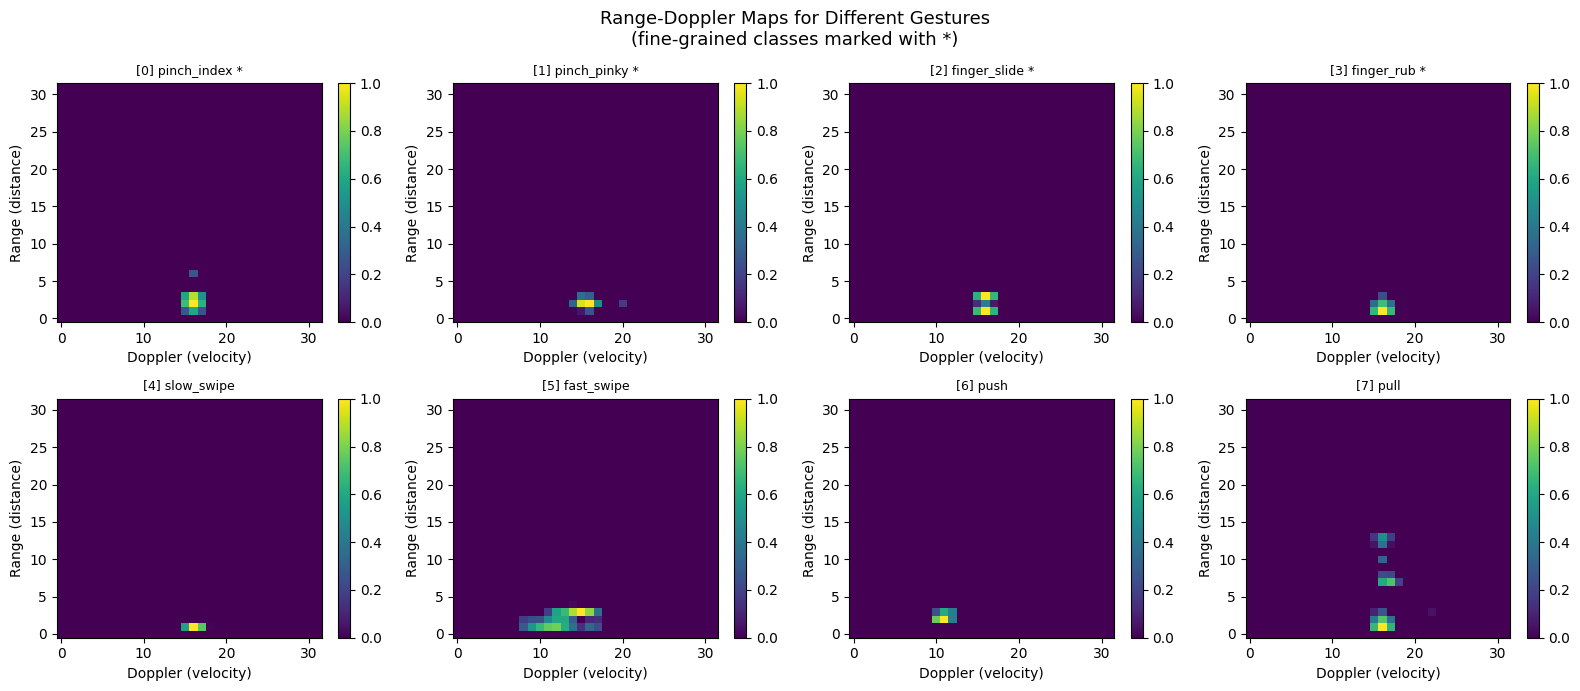

Notice how sparse the maps are — most pixels are near zero.
This sparsity makes fine-grained classes hard to distinguish.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Range-Doppler Maps for Different Gestures\n'
             '(fine-grained classes marked with *)', fontsize=13)

for g_idx in range(8):
    samples_g = [s for s in all_samples if s[1] == g_idx]
    if not samples_g:
        continue

    with h5py.File(samples_g[0][0], 'r') as f:
        frames = f['ch0'][()].reshape(-1, 32, 32)

    mid_frame = frames[len(frames) // 2]
    ax  = axes[g_idx // 4][g_idx % 4]
    im  = ax.imshow(mid_frame, cmap='viridis', aspect='auto', origin='lower')
    name = GESTURE_NAMES[g_idx]
    marker = ' *' if g_idx in FINE_GRAINED else ''
    ax.set_title(f'[{g_idx}] {name}{marker}', fontsize=9)
    ax.set_xlabel('Doppler (velocity)')
    ax.set_ylabel('Range (distance)')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('range_doppler_maps.png', dpi=100, bbox_inches='tight')
plt.show()
print('Notice how sparse the maps are — most pixels are near zero.')
print('This sparsity makes fine-grained classes hard to distinguish.')

## 6. Model Architecture

We build four components from scratch:
- `Encoder` — 3D-CNN that maps a radar clip to a feature vector
- `Classifier` — predicts the gesture class from features
- `DomainDiscriminator` — predicts subject identity (with gradient reversal)
- `Generator` + `GANDiscriminator` — conditional WGAN for data augmentation

In [8]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# --- Gradient Reversal Layer ---
# During forward pass it is an identity function.
# During backward pass it multiplies the gradient by -alpha,
# which forces the encoder to remove subject-specific information.
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)


# --- 3D Convolutional Encoder ---
# Input shape: (batch, 1, T, 32, 32)
# Output shape: (batch, feat_dim)
class Encoder(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((2, 2, 2)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, feat_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.fc(self.conv_layers(x))


# --- Gesture Classifier ---
class Classifier(nn.Module):
    def __init__(self, feat_dim=256, num_classes=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, z):
        return self.net(z)


# --- Domain Discriminator (predicts subject ID) ---
class DomainDiscriminator(nn.Module):
    def __init__(self, feat_dim=256, num_subjects=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_subjects),
        )

    def forward(self, z, alpha=1.0):
        return self.net(grad_reverse(z, alpha))


# --- Full DANN Model ---
class DANN(nn.Module):
    def __init__(self, feat_dim=256, num_classes=11, num_subjects=10):
        super().__init__()
        self.encoder     = Encoder(feat_dim)
        self.classifier  = Classifier(feat_dim, num_classes)
        self.domain_disc = DomainDiscriminator(feat_dim, num_subjects)

    def forward(self, x, alpha=1.0):
        z = self.encoder(x)
        return self.classifier(z), self.domain_disc(z, alpha)

    def predict(self, x):
        return self.classifier(self.encoder(x))


# --- Conditional Generator ---
# Takes a noise vector and a class label, outputs a fake radar clip
class Generator(nn.Module):
    def __init__(self, nz=100, num_classes=11, T=40, R=32, D=32):
        super().__init__()
        self.T, self.R, self.D = T, R, D
        self.label_emb = nn.Embedding(num_classes, 16)
        self.fc        = nn.Linear(nz + 16, 256 * 3 * 4 * 4)
        self.decoder   = nn.Sequential(
            nn.ConvTranspose3d(256, 128, (4,4,4), (2,2,2), (1,1,1)),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose3d(128, 64, (4,4,4), (2,2,2), (1,1,1)),
            nn.BatchNorm3d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose3d(64, 1, (3,4,4), (1,2,2), (1,1,1)),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        emb = self.label_emb(labels)
        x   = F.relu(self.fc(torch.cat([noise, emb], dim=1)))
        x   = self.decoder(x.view(-1, 256, 3, 4, 4))
        return F.interpolate(x, size=(self.T, self.R, self.D),
                             mode='trilinear', align_corners=False)


# --- GAN Discriminator ---
class GANDiscriminator(nn.Module):
    def __init__(self, num_classes=11, T=40, R=32, D=32):
        super().__init__()
        self.T, self.R, self.D = T, R, D
        self.label_emb = nn.Embedding(num_classes, T * R * D)
        self.net = nn.Sequential(
            nn.Conv3d(2, 32, 3, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(32, 64, 3, 2, 1), nn.BatchNorm3d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(64, 128, 3, 2, 1), nn.BatchNorm3d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(128, 1),
        )

    def forward(self, x, labels):
        emb = self.label_emb(labels).view(-1, 1, self.T, self.R, self.D)
        return self.net(torch.cat([x, emb], dim=1))


# Quick sanity check
model = DANN().to(device)
dummy = torch.randn(2, 1, 40, 32, 32).to(device)
g_out, d_out = model(dummy)
print(f'DANN output shapes: gesture={g_out.shape}, domain={d_out.shape}')

G = Generator(T=40).to(device)
noise  = torch.randn(2, 100).to(device)
labels = torch.zeros(2, dtype=torch.long).to(device)
print(f'Generator output shape: {G(noise, labels).shape}')
print('All models defined successfully.')

DANN output shapes: gesture=torch.Size([2, 11]), domain=torch.Size([2, 10])
Generator output shape: torch.Size([2, 1, 40, 32, 32])
All models defined successfully.


## 7. Phase 1 — Train the Conditional GAN

We use a Wasserstein GAN with gradient penalty (WGAN-GP). The gradient penalty is computed manually to enforce the Lipschitz constraint on the discriminator. This gives more stable training than the original GAN loss.

Only fine-grained class samples are used for GAN training.

In [9]:
import torch.optim as optim


def compute_gradient_penalty(discriminator, real, fake, labels, device):
    """
    WGAN-GP gradient penalty — implemented from scratch.
    Enforces ||grad D(x_hat)||_2 = 1 for interpolated samples.
    """
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)

    d_interp = discriminator(interpolated, labels)
    grads = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
    )[0]

    grads = grads.view(batch_size, -1)
    gp    = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp


def train_gan(data_root, epochs=100, batch_size=32,
              nz=100, lr=2e-4, lambda_gp=10.0, seq_len=40):
    num_classes = 11
    n_critic    = 5  # update discriminator 5x per generator update

    # Use only fine-grained samples for GAN training
    all_s  = load_file_list(data_root)
    fg_s   = [s for s in all_s if s[1] in FINE_GRAINED]
    print(f'Fine-grained samples available for GAN: {len(fg_s)}')

    dataset = SoliDataset(fg_s, seq_len=seq_len)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=True, num_workers=2, drop_last=True)

    G = Generator(nz=nz, num_classes=num_classes, T=seq_len).to(device)
    D = GANDiscriminator(num_classes=num_classes, T=seq_len).to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        loss_d_total = 0
        loss_g_total = 0
        num_batches  = 0

        for real_x, g_labels, _ in loader:
            real_x   = real_x.to(device)
            g_labels = g_labels.to(device)
            B        = real_x.size(0)

            # --- Update Discriminator ---
            for _ in range(n_critic):
                noise    = torch.randn(B, nz, device=device)
                fake_x   = G(noise, g_labels).detach()
                gp       = compute_gradient_penalty(D, real_x, fake_x,
                                                    g_labels, device)
                loss_d   = (D(fake_x, g_labels).mean()
                            - D(real_x, g_labels).mean()
                            + lambda_gp * gp)
                opt_D.zero_grad()
                loss_d.backward()
                opt_D.step()

            # --- Update Generator ---
            noise  = torch.randn(B, nz, device=device)
            fake_x = G(noise, g_labels)
            loss_g = -D(fake_x, g_labels).mean()
            opt_G.zero_grad()
            loss_g.backward()
            opt_G.step()

            loss_d_total += loss_d.item()
            loss_g_total += loss_g.item()
            num_batches  += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'D_loss: {loss_d_total/num_batches:.4f} | '
                  f'G_loss: {loss_g_total/num_batches:.4f}')

    os.makedirs('./checkpoints', exist_ok=True)
    torch.save(G.state_dict(), './checkpoints/generator_final.pt')
    print('Generator saved to ./checkpoints/generator_final.pt')
    return G


# Set GAN_EPOCHS = 100 for final submission
GAN_EPOCHS = 50

print(f'Starting GAN training for {GAN_EPOCHS} epochs...')
G_model = train_gan(DATA_ROOT, epochs=GAN_EPOCHS)

Starting GAN training for 50 epochs...
Fine-grained samples available for GAN: 1900


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch   1/50 | D_loss: 2.9298 | G_loss: 0.1824
Epoch  10/50 | D_loss: -56.4475 | G_loss: 23.4233
Epoch  20/50 | D_loss: -163.3466 | G_loss: 72.6109
Epoch  30/50 | D_loss: -305.1772 | G_loss: 139.6530
Epoch  40/50 | D_loss: -482.5146 | G_loss: 224.1624
Epoch  50/50 | D_loss: -693.5136 | G_loss: 325.3453
Generator saved to ./checkpoints/generator_final.pt


## 8. Generate Synthetic Samples and Compare with Real Data

Generated 800 synthetic samples (200 per fine-grained class)


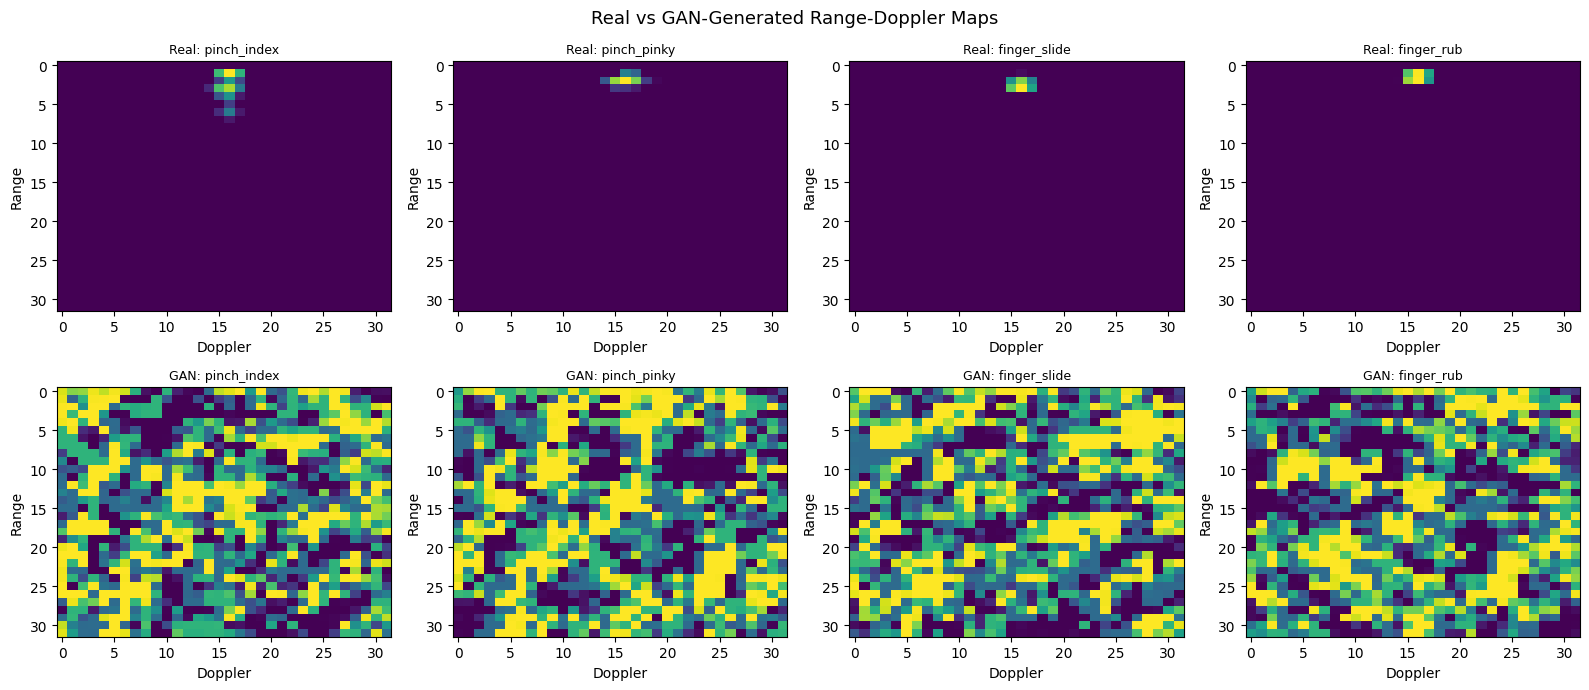

In [11]:
def generate_synthetic(gen_path, num_per_class=200,
                        nz=100, seq_len=40, num_classes=11):
    G = Generator(nz=nz, num_classes=num_classes, T=seq_len).to(device)
    G.load_state_dict(torch.load(gen_path, map_location=device))
    G.eval()

    synthetic = []
    with torch.no_grad():
        for cls in sorted(FINE_GRAINED):
            labels = torch.full((num_per_class,), cls,
                                dtype=torch.long, device=device)
            noise  = torch.randn(num_per_class, nz, device=device)
            fakes  = G(noise, labels).cpu()
            for i in range(num_per_class):
                synthetic.append((fakes[i], cls))

    print(f'Generated {len(synthetic)} synthetic samples '
          f'({num_per_class} per fine-grained class)')
    return synthetic


# Generate 200 synthetic samples per fine-grained class
synthetic_samples = generate_synthetic(
    './checkpoints/generator_final.pt',
    num_per_class=200
)

# Visual comparison: real vs generated
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Real vs GAN-Generated Range-Doppler Maps', fontsize=13)

for col, cls in enumerate(sorted(FINE_GRAINED)):
    # Real sample
    real_s = [s for s in all_samples if s[1] == cls]
    with h5py.File(real_s[0][0], 'r') as f:
        real_frame = f['ch0'][()].reshape(-1, 32, 32)[20]
    axes[0][col].imshow(real_frame, cmap='viridis', aspect='auto')
    axes[0][col].set_title(f'Real: {GESTURE_NAMES[cls]}', fontsize=9)

    # Generated sample
    fake_tensor = synthetic_samples[col][0]
    axes[1][col].imshow(fake_tensor[0, 20].numpy(), cmap='viridis', aspect='auto')
    axes[1][col].set_title(f'GAN: {GESTURE_NAMES[cls]}', fontsize=9)

for row in range(2):
    for ax in axes[row]:
        ax.set_xlabel('Doppler')
        ax.set_ylabel('Range')

plt.tight_layout()
plt.savefig('real_vs_generated.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Phase 2 — Train the DANN Classifier

The GRL alpha is scheduled to ramp from 0 to 1 using a sigmoid schedule. This prevents the domain loss from destabilizing the gesture classifier early in training.

In [12]:
def alpha_schedule(epoch, total_epochs):
    """Ramp GRL alpha from 0 to 1 using a sigmoid schedule."""
    p = epoch / total_epochs
    return 2.0 / (1.0 + torch.exp(torch.tensor(-10.0 * p)).item()) - 1.0


def train_one_epoch(model, loader, optimizer, criterion,
                    device, alpha, lambda_domain):
    model.train()
    total_g_loss = 0
    total_d_loss = 0
    total_samples = 0

    for x, g_labels, s_labels in loader:
        x        = x.to(device)
        g_labels = g_labels.to(device)
        s_labels = s_labels.to(device)

        # Only real samples (not synthetic) have valid subject labels
        domain_mask = (s_labels >= 0)

        g_logits, d_logits = model(x, alpha=alpha)

        loss_g = criterion(g_logits, g_labels)
        if domain_mask.any():
            loss_d = criterion(d_logits[domain_mask], s_labels[domain_mask])
        else:
            loss_d = torch.tensor(0.0, device=device)

        total_loss = loss_g + lambda_domain * loss_d
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        n = x.size(0)
        total_g_loss  += loss_g.item() * n
        total_d_loss  += loss_d.item() * n
        total_samples += n

    return total_g_loss / total_samples, total_d_loss / total_samples


def evaluate_model(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x, g_labels, _ in loader:
            preds = model.predict(x.to(device)).argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels.append(g_labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    overall_acc = (all_preds == all_labels).float().mean().item()

    # Fine-grained class accuracy
    fg_mask = torch.zeros(len(all_labels), dtype=torch.bool)
    for c in FINE_GRAINED:
        fg_mask |= (all_labels == c)

    fg_acc = 0.0
    if fg_mask.any():
        fg_acc = (all_preds[fg_mask] == all_labels[fg_mask]).float().mean().item()

    return overall_acc, fg_acc


def train_dann(data_root, synthetic_data, epochs=50, batch_size=32,
               lr=1e-3, lambda_domain=0.1, seq_len=40):
    all_s  = load_file_list(data_root)
    folds  = two_fold_split(all_s)
    results = []

    for fold_idx, (train_s, test_s) in enumerate(folds):
        print(f'\n{"="*55}')
        print(f'  Fold {fold_idx + 1}/2   train={len(train_s)}   test={len(test_s)}')
        print(f'{"="*55}')

        train_loader, test_loader = make_loaders(
            train_s, test_s,
            synthetic=synthetic_data,
            batch_size=batch_size,
            seq_len=seq_len
        )

        model     = DANN(feat_dim=256, num_classes=11, num_subjects=10).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        criterion = nn.CrossEntropyLoss()

        best_acc = 0.0
        history  = {'acc': [], 'fg_acc': [], 'epoch': []}

        for epoch in range(1, epochs + 1):
            alpha  = alpha_schedule(epoch, epochs)
            lg, ld = train_one_epoch(model, train_loader, optimizer,
                                     criterion, device, alpha, lambda_domain)
            scheduler.step()

            if epoch % 5 == 0 or epoch == epochs:
                acc, fg_acc = evaluate_model(model, test_loader, device)
                history['acc'].append(acc)
                history['fg_acc'].append(fg_acc)
                history['epoch'].append(epoch)
                print(f'  Epoch {epoch:3d} | '
                      f'Gesture loss: {lg:.4f}  Domain loss: {ld:.4f} | '
                      f'Acc: {acc:.2%}  FG-Acc: {fg_acc:.2%}')

                if acc > best_acc:
                    best_acc = acc
                    save_path = f'./checkpoints/best_model_fold{fold_idx}.pt'
                    torch.save(model.state_dict(), save_path)

        print(f'\n  Best accuracy (fold {fold_idx + 1}): {best_acc:.2%}')
        results.append((best_acc, history))

    mean_acc = sum(r[0] for r in results) / len(results)
    print(f'\n  Mean accuracy across folds: {mean_acc:.2%}')
    return results


# Set DANN_EPOCHS = 50 for final submission
DANN_EPOCHS = 30

print(f'Starting DANN training for {DANN_EPOCHS} epochs...')
fold_results = train_dann(DATA_ROOT, synthetic_samples, epochs=DANN_EPOCHS)

Starting DANN training for 30 epochs...

  Fold 1/2   train=1925   test=3300
  Epoch   5 | Gesture loss: 0.2039  Domain loss: 1.4487 | Acc: 83.94%  FG-Acc: 68.25%
  Epoch  10 | Gesture loss: 0.0625  Domain loss: 1.4300 | Acc: 86.91%  FG-Acc: 78.25%
  Epoch  15 | Gesture loss: 0.0254  Domain loss: 1.4396 | Acc: 88.03%  FG-Acc: 75.25%
  Epoch  20 | Gesture loss: 0.0111  Domain loss: 1.4347 | Acc: 84.67%  FG-Acc: 75.42%
  Epoch  25 | Gesture loss: 0.0095  Domain loss: 1.4287 | Acc: 90.52%  FG-Acc: 78.33%
  Epoch  30 | Gesture loss: 0.0051  Domain loss: 1.4405 | Acc: 90.61%  FG-Acc: 78.17%

  Best accuracy (fold 1): 90.61%

  Fold 2/2   train=3300   test=1925
  Epoch   5 | Gesture loss: 0.2354  Domain loss: 1.4659 | Acc: 86.34%  FG-Acc: 76.71%
  Epoch  10 | Gesture loss: 0.0746  Domain loss: 1.4434 | Acc: 92.31%  FG-Acc: 86.00%
  Epoch  15 | Gesture loss: 0.0392  Domain loss: 1.4306 | Acc: 93.35%  FG-Acc: 89.71%
  Epoch  20 | Gesture loss: 0.0143  Domain loss: 1.4487 | Acc: 95.12%  FG-Acc:

## 10. Training Curves

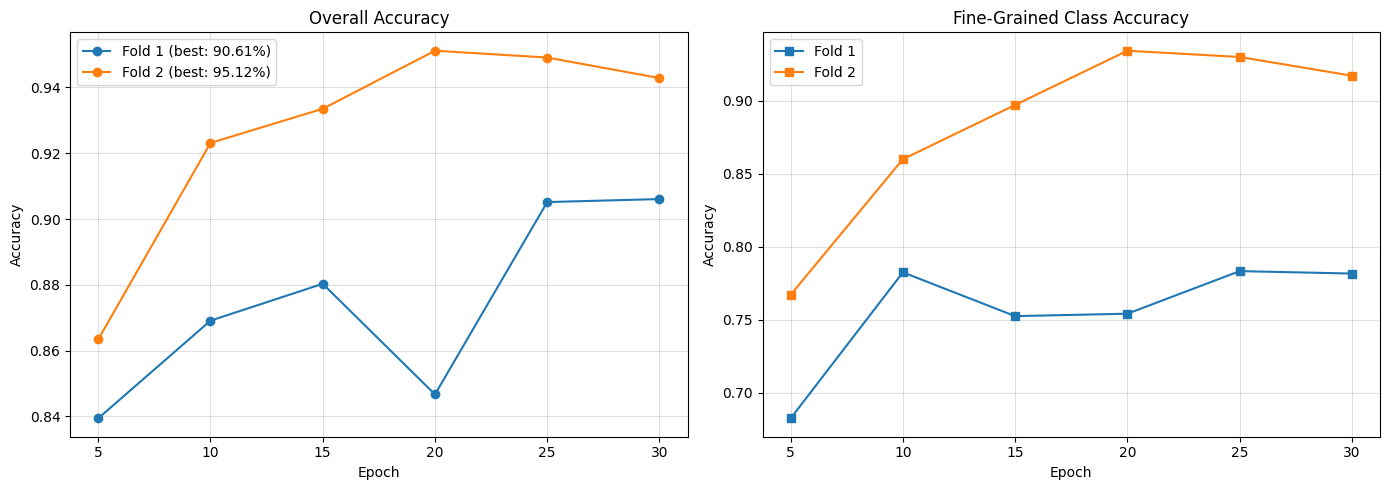

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for fold_idx, (best_acc, hist) in enumerate(fold_results):
    ax1.plot(hist['epoch'], hist['acc'],
             marker='o', label=f'Fold {fold_idx + 1} (best: {best_acc:.2%})')
    ax2.plot(hist['epoch'], hist['fg_acc'],
             marker='s', label=f'Fold {fold_idx + 1}')

ax1.set_title('Overall Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.set_title('Fine-Grained Class Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Detailed Per-Class Accuracy Report

In [15]:
def per_class_report(model, loader, device, num_classes=11):
    model.eval()
    counts  = torch.zeros(num_classes, dtype=torch.long)
    correct = torch.zeros(num_classes, dtype=torch.long)

    with torch.no_grad():
        for x, g_labels, _ in loader:
            preds = model.predict(x.to(device)).argmax(dim=1).cpu()
            for c in range(num_classes):
                mask       = (g_labels == c)
                counts[c]  += mask.sum()
                correct[c] += (preds[mask] == g_labels[mask]).sum()

    print(f'\n{"="*60}')
    print(f"  {'Class':<18} {'N':>5}  {'Accuracy':>9}  Bar")
    print(f"  {'-'*58}")

    for c in range(num_classes):
        if counts[c] == 0:
            continue
        acc  = (correct[c] / counts[c]).item()
        name = GESTURE_NAMES[c]
        bar  = '#' * int(acc * 25)
        fg   = ' *' if c in FINE_GRAINED else ''
        print(f"  {name:<18} {counts[c].item():>5}  {acc:>8.2%}  {bar}{fg}")

    print(f"  {'-'*58}")
    overall = correct.sum().item() / counts.sum().item()
    fg_idx  = list(FINE_GRAINED)
    fg_acc  = (correct[fg_idx].sum() / counts[fg_idx].sum()).item()
    print(f"  {'Overall':<18} {counts.sum().item():>5}  {overall:>8.2%}")
    print(f"  {'Fine-grained avg':<18} {'':>5}  {fg_acc:>8.2%}")
    print(f'{"="*60}')
    print('  * = fine-grained class')
    return overall, fg_acc


# Evaluate both folds
all_s_eval  = load_file_list(DATA_ROOT)
folds_eval  = two_fold_split(all_s_eval)

for fold_idx in range(2):
    _, test_s = folds_eval[fold_idx]

    test_ds = SoliDataset(test_s, seq_len=40)
    test_loader_eval = DataLoader(test_ds, batch_size=32,
                                  shuffle=False, num_workers=2)

    ckpt = f'./checkpoints/best_model_fold{fold_idx}.pt'
    best_model = DANN().to(device)
    best_model.load_state_dict(torch.load(ckpt, map_location=device))

    print(f'\nFold {fold_idx + 1} — Detailed Per-Class Report:')
    per_class_report(best_model, test_loader_eval, device)


Fold 1 — Detailed Per-Class Report:

  Class                  N   Accuracy  Bar
  ----------------------------------------------------------
  pinch_index          300    86.00%  ##################### *
  pinch_pinky          300    97.00%  ######################## *
  finger_slide         300    76.00%  ################## *
  finger_rub           300    53.67%  ############# *
  slow_swipe           300    96.33%  ########################
  fast_swipe           300    99.33%  ########################
  push                 300    99.33%  ########################
  pull                 300    98.00%  ########################
  palm_tilt            300    99.33%  ########################
  circle               300    95.33%  #######################
  palm_hold            300    96.33%  ########################
  ----------------------------------------------------------
  Overall             3300    90.61%
  Fine-grained avg            78.17%
  * = fine-grained class

Fold 2 — Detailed

## 12. Ablation Study


In [16]:
def run_ablation_variant(name, train_s, test_s, synthetic_data,
                          use_domain_loss, epochs=20, batch_size=32, lr=1e-3):
    aug  = synthetic_data if name in ('+GAN', 'Full') else None
    lam  = 0.1 if use_domain_loss else 0.0

    tr_loader, te_loader = make_loaders(train_s, test_s,
                                         synthetic=aug,
                                         batch_size=batch_size)
    model = DANN().to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    ce    = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        alpha = alpha_schedule(epoch, epochs) if use_domain_loss else 0.0
        train_one_epoch(model, tr_loader, opt, ce, device, alpha, lam)

    return evaluate_model(model, te_loader, device)


ABLATION_VARIANTS = [
    ('Baseline', False),
    ('+GAN',     False),
    ('+DANN',    True),
    ('Full',     True),
]

ABLATION_EPOCHS = 20

all_s_abl   = load_file_list(DATA_ROOT)
folds_abl   = two_fold_split(all_s_abl)
abl_results = {v[0]: [] for v in ABLATION_VARIANTS}

for fold_idx, (train_s, test_s) in enumerate(folds_abl):
    print(f'\nFold {fold_idx + 1}/2')
    for name, use_dann in ABLATION_VARIANTS:
        acc, fg = run_ablation_variant(
            name, train_s, test_s,
            synthetic_samples, use_dann,
            epochs=ABLATION_EPOCHS
        )
        abl_results[name].append((acc, fg))
        print(f'  {name:<12}  Overall: {acc:.2%}   Fine-grained: {fg:.2%}')

print(f'\n{"="*60}')
print(f"  {'Method':<12}  {'Overall (mean)':>16}  {'FG Acc (mean)':>14}")
print(f"  {'-'*58}")
for name, _ in ABLATION_VARIANTS:
    fold_data = abl_results[name]
    mean_acc  = sum(r[0] for r in fold_data) / len(fold_data)
    mean_fg   = sum(r[1] for r in fold_data) / len(fold_data)
    print(f"  {name:<12}  {mean_acc:>16.2%}  {mean_fg:>14.2%}")
print(f'{"="*60}')


Fold 1/2
  Baseline      Overall: 88.18%   Fine-grained: 81.75%
  +GAN          Overall: 80.61%   Fine-grained: 75.75%
  +DANN         Overall: 89.09%   Fine-grained: 75.92%
  Full          Overall: 89.82%   Fine-grained: 77.00%

Fold 2/2
  Baseline      Overall: 93.40%   Fine-grained: 90.00%
  +GAN          Overall: 95.17%   Fine-grained: 92.57%
  +DANN         Overall: 80.78%   Fine-grained: 71.00%
  Full          Overall: 93.56%   Fine-grained: 94.14%

  Method          Overall (mean)   FG Acc (mean)
  ----------------------------------------------------------
  Baseline                90.79%          85.87%
  +GAN                    87.89%          84.16%
  +DANN                   84.94%          73.46%
  Full                    91.69%          85.57%
